## Transfer learning

Here, I will continue working on the chest X-ray images, from [Kermany et al. 2018](https://www.sciencedirect.com/science/article/pii/S0092867418301545?via%3Dihub), but this time I will use transfer learning described in the original paper.

The base model I will re-use is [ResNet50](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html) from [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385). With inspirations from [this github repo](https://github.com/liyu95/Deep_learning_examples/blob/master/4.ResNet_X-ray_classification/Densenet_fine_tune.ipynb) and [this kaggle thread](https://www.kaggle.com/code/iamsdt/transferlearning-pytorch-resnet-50).


In [ ]:
# Standard library
import os
import sys
import math
import copy

# Scientific stack / plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch & torchvision
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# If you’re using the new transforms API, prefer v2:
from torchvision.transforms import v2 as T
# (If you specifically need the old API, use: `import torchvision.transforms as T`)
from torchvision.models import (
    resnet18,
    resnet50,
    ResNet18_Weights,
    ResNet50_Weights,
)
import torchvision
from torchvision.io import read_image

# Image I/O
from PIL import Image

# Model summary
import pytorch_model_summary as pms

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# Go to project root
os.chdir("/home/katwre/projects/tmp_ml/ML-projects/CNN_and_TransferLearning_Xray")

# Add the src directory to Python path
sys.path.append(os.path.join(os.getcwd(), "src"))

from src.train import main as train_main
from src.model import build_model, describe_model

# Get cpu, gpu or mps device for training.
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {DEVICE} device")

Using cpu device


In [13]:
# Best available weights (currently alias for IMAGENET1K_V2)
# Note that these weights may change across versions
RN50_model = resnet50(weights=ResNet50_Weights.DEFAULT).to(DEVICE)
RN50_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

The inference transforms are available at `ResNet50_Weights.IMAGENET1K_V2.transforms` 
and perform the following preprocessing operations: 
 * Accepts PIL.Image, batched (B, C, H, W) and single (C, H, W) image torch.Tensor objects. 
 * The images are resized to resize_size=[232] using interpolation=InterpolationMode.BILINEAR, 
 * followed by a central crop of crop_size=[224]. 
 * Finally the values are first rescaled to [0.0, 1.0] 
 * then normalized using mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225].

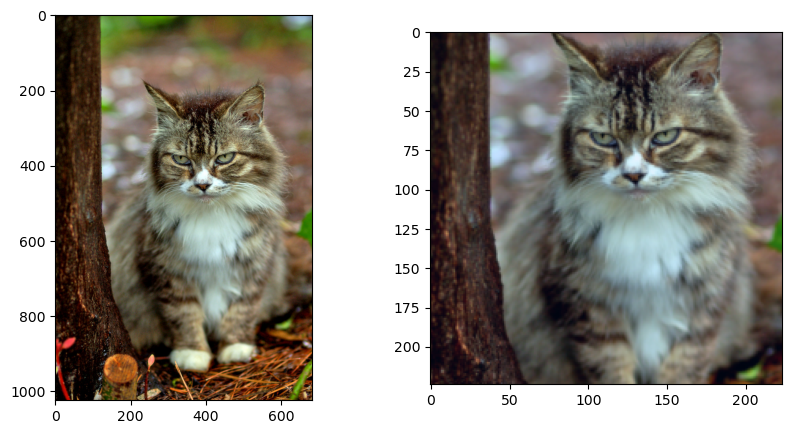

In [14]:
def make_np_img( img ):
    np_img = torch.moveaxis(img,0,2).numpy()    
    m = np_img.min()
    M = np_img.max()
    r = M-m
    return (np_img - m)/r

from torchvision.io import read_image
RN50_transformer = ResNet50_Weights.IMAGENET1K_V2.transforms( antialias=True)

cat = read_image( "data/cat.jpg" )
cat_t = RN50_transformer(cat)

fig,ax = plt.subplots(1,2 , figsize = (10,5))
## Tensor are in C,H,W shape, but imshow wants H,W,C
## so we move axis 0 to index 2
ax[0].imshow( torch.moveaxis(cat,0,2).numpy())  
ax[1].imshow( make_np_img( cat_t ))

In [15]:
RN50_dategories = np.array( ResNet50_Weights.DEFAULT.meta['categories'] )
print("RN50_dategories[:5]: ", RN50_dategories[:5])

cat_t = cat_t.to(DEVICE)
with torch.no_grad():
    pred = RN50_model(cat_t.unsqueeze(0))
    class_probas = pred.squeeze(0).softmax(0).cpu()
    print( "class proba shape",class_probas.shape )
    print( 'probas:    ', class_probas[:5] , '...' )
    print( 'categories:',RN50_dategories[:5] , '...')

RN50_dategories[:5]:  ['tench' 'goldfish' 'great white shark' 'tiger shark' 'hammerhead']
class proba shape torch.Size([1000])
probas:     tensor([0.0010, 0.0007, 0.0011, 0.0011, 0.0011]) ...
categories: ['tench' 'goldfish' 'great white shark' 'tiger shark' 'hammerhead'] ...


LEt's run a forward pass of a pre-trained ResNet-50 model on a given image, visualize the input, its transformed tensor, and top-5 predicted classes.

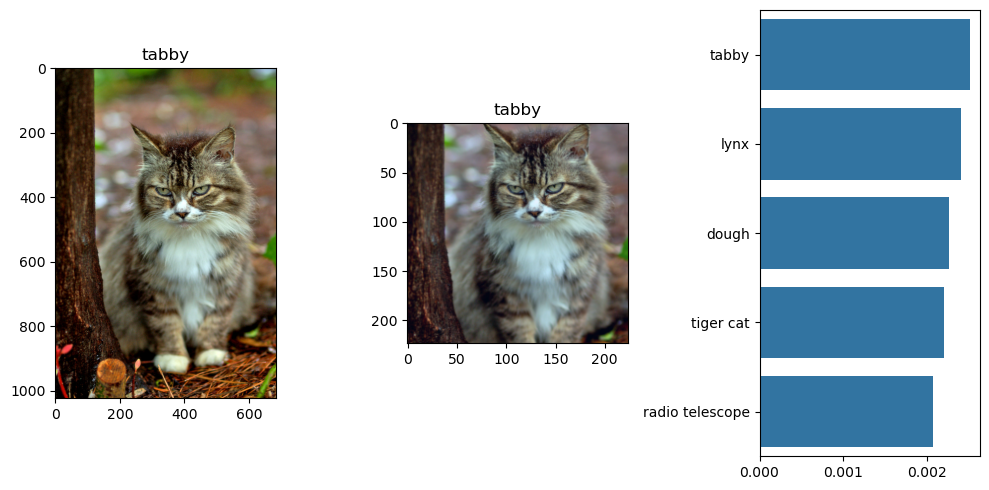

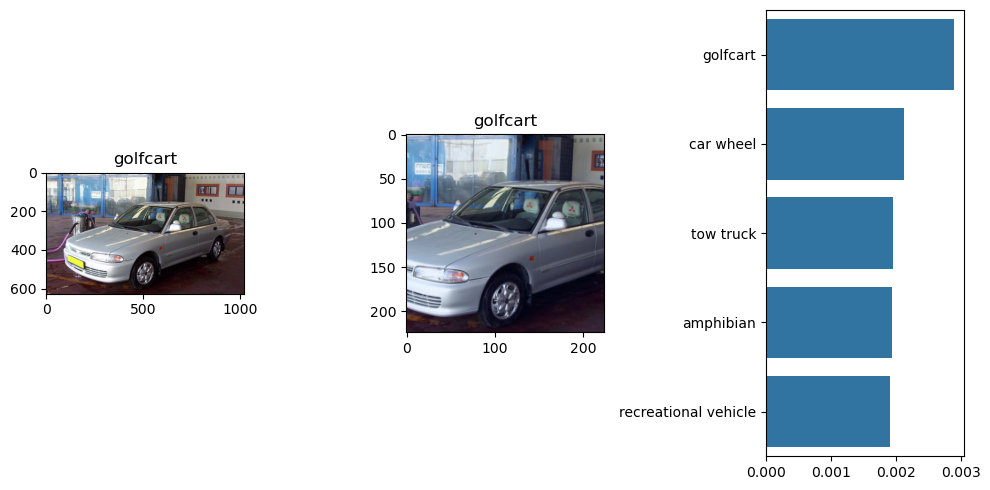

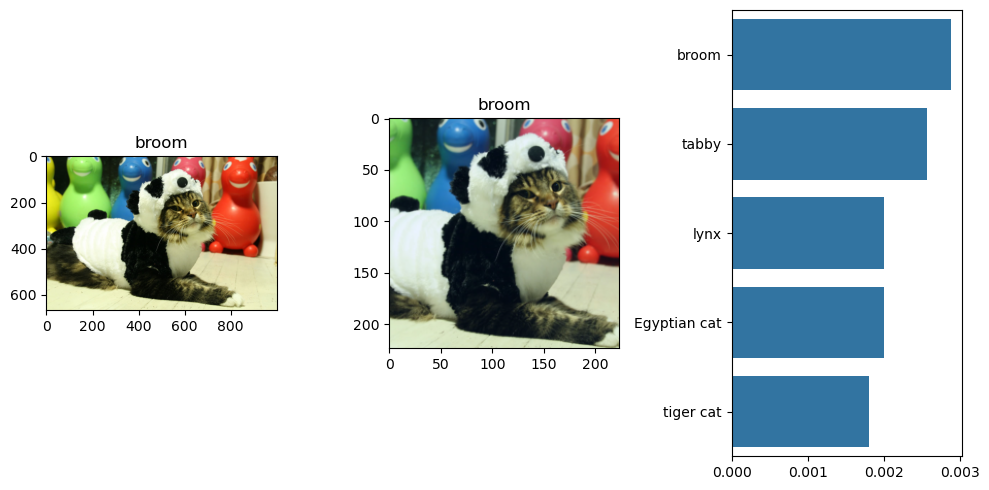

In [16]:
def RN50_predict( img ):
    img_t = RN50_transformer( img )

    img_t = img_t.to(DEVICE)
    with torch.no_grad():
        pred = RN50_model(img_t.unsqueeze(0))
        class_probas = pred.squeeze(0).softmax(0)
    
    order = np.argsort( class_probas.cpu().numpy()  )[::-1]
    
    fig,ax = plt.subplots(1,3 , figsize = (10,5))
    ax[0].imshow(torch.moveaxis(img,0,2).cpu().numpy())
    ax[0].set_title(RN50_dategories[order[0]])
    ax[1].imshow( make_np_img( img_t.cpu() ) )
    ax[1].set_title(RN50_dategories[order[0]])
    
    sns.barplot( x = class_probas.cpu().numpy()[order[:5]], 
             y = RN50_dategories[order[:5]] , ax = ax[2])
    plt.tight_layout()

RN50_predict( cat )
RN50_predict( read_image("data/car.jpg") )
RN50_predict( read_image("data/pandas_cat.jpg") )


Now lets try on the xray images! As expected it doesn't make sense.

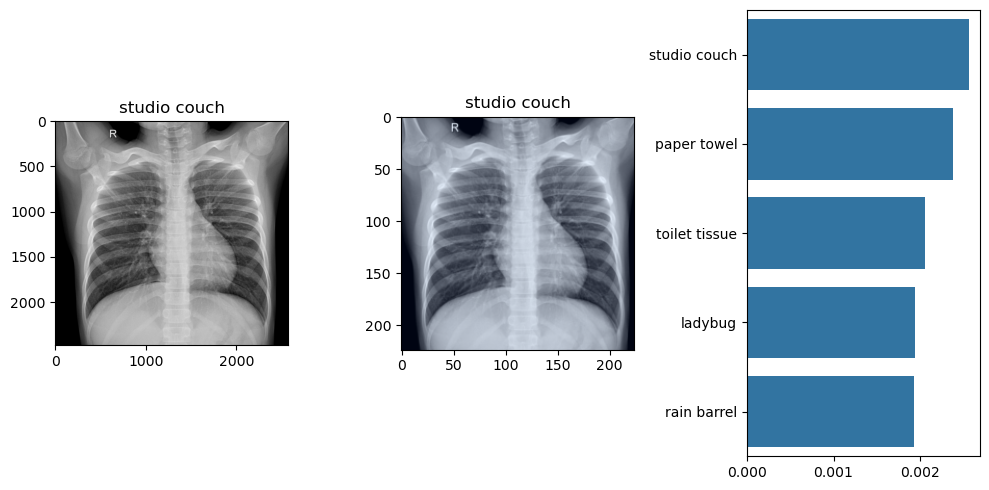

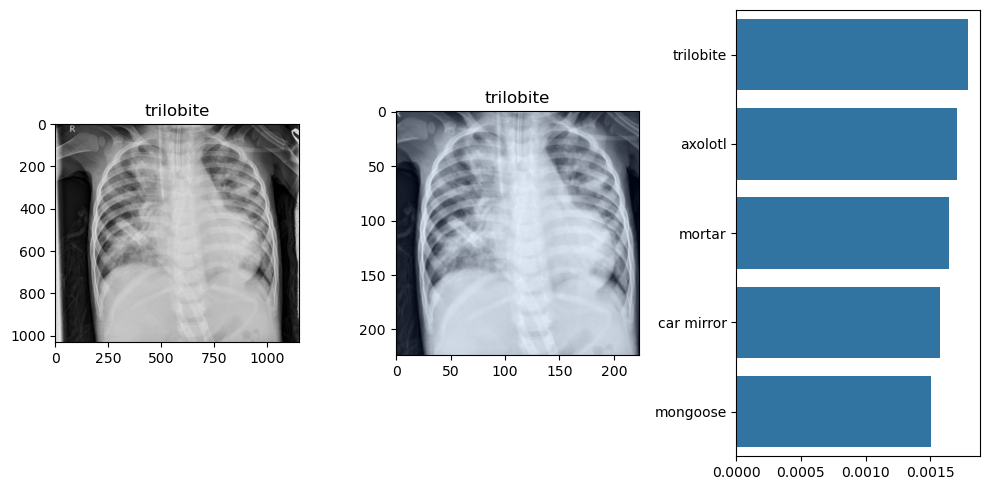

In [17]:

## force the image to be RGB
img = read_image("data/NORMAL-1003233-0001.jpeg" , 
                 mode=torchvision.io.ImageReadMode.RGB )

RN50_predict(img)

img = read_image("data/BACTERIA-1008087-0001.jpeg" , 
                 mode=torchvision.io.ImageReadMode.RGB )

RN50_predict(img)

## Setting up transfer-learning

Rather than train a model from scratch as I did previously, I will leverage this complex model with [transfer learning](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-deep-learning-tips-and-tricks#parameter-tuning).

So I will freeze most layers of resnet50 and plug our own classifier on top.

![small Transfer Learning representation from https://stanford.edu/~shervine/teaching/cs-230/](https://stanford.edu/~shervine/teaching/cs-230/illustrations/transfer-learning-small-ltr.png?bee5e73de8fb2c6297a3a88804fabf5e)

Resnet design: 

In [18]:
cat_t = RN50_transformer(cat).to(DEVICE)
print(pms.summary(RN50_model, cat_t.unsqueeze(0) , show_input=True))

------------------------------------------------------------------------------
           Layer (type)           Input Shape         Param #     Tr. Param #
               Conv2d-1      [1, 3, 224, 224]           9,408           9,408
          BatchNorm2d-2     [1, 64, 112, 112]             128             128
                 ReLU-3     [1, 64, 112, 112]               0               0
            MaxPool2d-4     [1, 64, 112, 112]               0               0
           Bottleneck-5       [1, 64, 56, 56]          75,008          75,008
           Bottleneck-6      [1, 256, 56, 56]          70,400          70,400
           Bottleneck-7      [1, 256, 56, 56]          70,400          70,400
           Bottleneck-8      [1, 256, 56, 56]         379,392         379,392
           Bottleneck-9      [1, 512, 28, 28]         280,064         280,064
          Bottleneck-10      [1, 512, 28, 28]         280,064         280,064
          Bottleneck-11      [1, 512, 28, 28]         280,064  

In [19]:
print(RN50_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Now, I'll freeze all layers by setting their parameters .requires_grad=False

In [20]:
# Get input dimension before replacing the layer
input_dim = RN50_model.fc[0].in_features if isinstance(RN50_model.fc, nn.Sequential) else RN50_model.fc.in_features

# I freeze all layers by setting their parameters .requires_grad=False
for param in RN50_model.parameters():
    param.requires_grad = False

# the layer I want to replace is called fc
# Parameters of newly constructed modules are set to requires_grad=True by default
#input_dim = RN50_model.fc.in_features

RN50_model.fc = nn.Sequential(nn.Linear(input_dim , 1),
                              nn.Sigmoid() )
cat_t = RN50_transformer(cat).to(DEVICE)
print(pms.summary(RN50_model, cat_t.unsqueeze(0) , show_input=True))


------------------------------------------------------------------------------
           Layer (type)           Input Shape         Param #     Tr. Param #
               Conv2d-1      [1, 3, 224, 224]           9,408               0
          BatchNorm2d-2     [1, 64, 112, 112]             128               0
                 ReLU-3     [1, 64, 112, 112]               0               0
            MaxPool2d-4     [1, 64, 112, 112]               0               0
           Bottleneck-5       [1, 64, 56, 56]          75,008               0
           Bottleneck-6      [1, 256, 56, 56]          70,400               0
           Bottleneck-7      [1, 256, 56, 56]          70,400               0
           Bottleneck-8      [1, 256, 56, 56]         379,392               0
           Bottleneck-9      [1, 512, 28, 28]         280,064               0
          Bottleneck-10      [1, 512, 28, 28]         280,064               0
          Bottleneck-11      [1, 512, 28, 28]         280,064  

Setup data loaders.

In [21]:
read_image_rgb = lambda x : read_image(x , mode=torchvision.io.ImageReadMode.RGB)

train_dataset = torchvision.datasets.ImageFolder('data/chest_xray_224/train', 
                                         loader = read_image_rgb,
                                         transform = RN50_transformer,
                                         target_transform = lambda x : torch.Tensor([x])  )
valid_dataset = torchvision.datasets.ImageFolder('data/chest_xray_224/test', 
                                         loader = read_image_rgb,
                                         transform = RN50_transformer,
                                         target_transform = lambda x : torch.Tensor([x])   )
    
    
batch_size = 64
train_dataloader = DataLoader( dataset= train_dataset , shuffle=True , batch_size = batch_size )
valid_dataloader = DataLoader( dataset= valid_dataset , shuffle=True , batch_size = batch_size )

X,y = next(iter(train_dataloader))
print(X.shape , y.shape)

loss = nn.BCELoss()

with torch.no_grad():
    pred = RN50_model(X.to(DEVICE))
    print(pred.shape)
    print( 'avg loss:', loss( pred , y.to(DEVICE) ) )

torch.Size([64, 3, 224, 224]) torch.Size([64, 1])
torch.Size([64, 1])
avg loss: tensor(0.6878)


From there I would train the model as one usually does. However, in that particular case you can notice that just predicting 1 batch of 64 images took almost 4s on my measly CPU. So to go through the 5,858 images of the dataset: ((4/64)*5858)/60 -> 6 minutes!

So I would have fairly long epochs, and that is without even counting the backward pass. Now, I could upgrade to a computer with a good GPU, but I could also apply reason like follow:
 * We have fixed all layers of Resnet50, except the last
 * So at each epoch I compute the same thing, except for the last component
 * Going through all these layers is time consuming
 * Why not go though all these fixed layers once, and then train a model on this
 
Basically, I would use a truncated Resnet50 model as a way to embed our 224x224 image (~50,176 pixels) into a 2048 feature space. And then I would train a classifier from that space.

In [22]:
## I modified the last layer so it does not modify the output and compute the embedding for 1 batch.
#RN50_model.fc = nn.Identity()
#
#with torch.no_grad():
#    X,y = next(iter(train_dataloader))
#    
#    embedding = RN50_model(X.to(DEVICE))
#
#print( embedding.shape )
#
## This takes around 7 mins
#train_dataloader_IMG = copy.deepcopy(train_dataloader)
#valid_dataloader_IMG = copy.deepcopy(valid_dataloader)
#RN50_model.fc = nn.Identity()
#
#train_embedding = torch.Tensor()
#train_Ys = torch.Tensor()
#
#with torch.no_grad():
#    
#    for X,y in train_dataloader_IMG:
#    
#        embedding = RN50_model(X.to(DEVICE)).to("cpu")
#        train_embedding = torch.concat((train_embedding,embedding))
#        train_Ys = torch.concat((train_Ys,y))
#
#print( train_embedding.shape )
#print( train_Ys.shape )
#
#valid_embedding = torch.Tensor()
#valid_Ys = torch.Tensor()
#
#with torch.no_grad():
#    
#    for X,y in valid_dataloader_IMG:
#    
#        embedding = RN50_model(X.to(DEVICE)).to("cpu")
#        valid_embedding = torch.concat((valid_embedding,embedding))
#        valid_Ys = torch.concat((valid_Ys,y))
#
#print( valid_embedding.shape )
#print( valid_Ys.shape )
#
## saving to a file
#torch.save(train_embedding, 'outputs/tl_chest_Xray_train_embed.pt')
#torch.save(train_Ys, 'outputs/tl_chest_Xray_train_y.pt')
#torch.save(valid_embedding, 'outputs/tl_chest_Xray_valid_embed.pt')
#torch.save(valid_Ys, 'outputs/tl_chest_Xray_valid_y.pt')

torch.Size([64, 2048])
torch.Size([5232, 2048])
torch.Size([5232, 1])
torch.Size([624, 2048])
torch.Size([624, 1])


In [23]:

class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt'):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change to qualify as an improvement.
            path (str): Path for saving the best model.
        """
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        if self.best_loss == np.inf:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Saves model when validation loss decreases."""
        if self.verbose:
            print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...")
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


Deep_LR(
  (layers): Sequential(
    (0): Linear(in_features=2048, out_features=1, bias=True)
    (1): Sigmoid()
  )
)


/tmp/ipykernel_15534/3659053346.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_embedding = torch.load('outputs/tl_chest_Xray_train_embed.pt')
/tmp/ipykernel_15534

train accuracy: 0.37213302752293576
valid accuracy: 0.4358974358974359
Train loss: 0.699519  [   64/ 5232]
Train loss: 0.693857  [  128/ 5232]
Train loss: 0.688466  [  192/ 5232]
Train loss: 0.687803  [  256/ 5232]
Train loss: 0.687655  [  320/ 5232]
Train loss: 0.685361  [  384/ 5232]
Train loss: 0.682155  [  448/ 5232]
Train loss: 0.684970  [  512/ 5232]
Train loss: 0.680067  [  576/ 5232]
Train loss: 0.680674  [  640/ 5232]
Train loss: 0.673115  [  704/ 5232]
Train loss: 0.673425  [  768/ 5232]
Train loss: 0.668391  [  832/ 5232]
Train loss: 0.669671  [  896/ 5232]
Train loss: 0.665446  [  960/ 5232]
Train loss: 0.682242  [ 1024/ 5232]
Train loss: 0.665925  [ 1088/ 5232]
Train loss: 0.675600  [ 1152/ 5232]
Train loss: 0.663276  [ 1216/ 5232]
Train loss: 0.662165  [ 1280/ 5232]
Train loss: 0.669197  [ 1344/ 5232]
Train loss: 0.658317  [ 1408/ 5232]
Train loss: 0.655108  [ 1472/ 5232]
Train loss: 0.654918  [ 1536/ 5232]
Train loss: 0.668719  [ 1600/ 5232]
Train loss: 0.652510  [ 1664/

/tmp/ipykernel_15534/3659053346.py:173: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('checkpoint.pt'))


train accuracy: 0.9749617737003058
valid accuracy: 0.8637820512820513


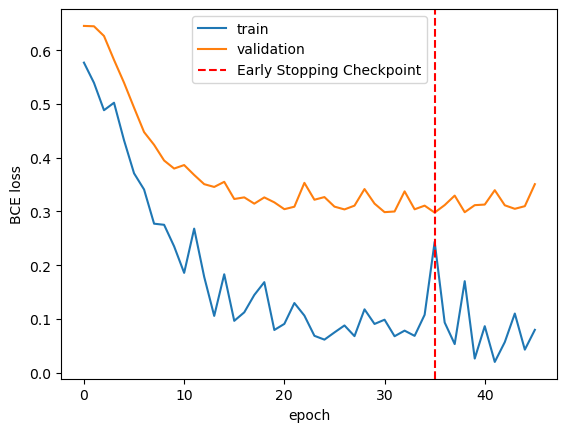

In [24]:
# Load previous computations
train_embedding = torch.load('outputs/tl_chest_Xray_train_embed.pt')
train_Ys = torch.load('outputs/tl_chest_Xray_train_y.pt')
valid_embedding = torch.load('outputs/tl_chest_Xray_valid_embed.pt')
valid_Ys = torch.load('outputs/tl_chest_Xray_valid_y.pt')

# create your dataset
train_dataset = TensorDataset( train_embedding,
                               train_Ys) 

batch_size = 64

## creating a dataloader
train_dataloader = DataLoader( train_dataset , shuffle = True , batch_size = batch_size ) 

# create your dataset
valid_dataset = TensorDataset( valid_embedding,
                               valid_Ys) 


## creating a dataloader
valid_dataloader = DataLoader(valid_dataset , shuffle = True , batch_size = batch_size )

class Deep_LR(torch.nn.Module):
    
    def __init__(self , input_dim = 2048 , 
                         hidden_dim=[] ,
                         dropout_fraction = 0.0):
        super().__init__()
        
        self.layers = nn.Sequential(  )
        
        # each layer is made of a linear layer with a ReLu activation and a DropOut Layer
        for i in range(len(hidden_dim)):
            self.layers.append( nn.Linear(input_dim, hidden_dim[i]) )
            self.layers.append( nn.ReLU() )
            self.layers.append( nn.Dropout(dropout_fraction) )
            input_dim = hidden_dim[i] ## update the input dimension for the next layer
        
        self.layers.append( nn.Linear(input_dim, 1) )
        self.layers.append( nn.Sigmoid() )
        
    def forward(self, x):
        out = self.layers(x)
        return out


model = Deep_LR().to(DEVICE)
print(model)

## we also define this to easily get accuracy 
def get_model_accuracy(model, dataloader):
    Ys = np.array([] , dtype = 'float32' )
    Ps = np.array([], dtype = 'float32' )
    with torch.no_grad():
        for X,y in dataloader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)
            pred = model(X)

            Ys = np.concatenate([Ys, y.squeeze().numpy()])
            Ps = np.concatenate([Ps, (pred>0.5).squeeze().numpy()])

    return np.mean( Ys == Ps )

def train(dataloader, model, loss_fn, optimizer ,  echo = True , echo_batch = False):
    
    size = len(dataloader.dataset) # how many batches do we have
    model.train() #     Sets the module in training mode.
    
    for batch, (X,y) in enumerate(dataloader): # for each batch
        X = X.to(DEVICE) # send the data to the GPU or whatever device you use for training
        y = y.to(DEVICE) # send the data to the GPU or whatever device you use for training

        # Compute prediction error
        pred = model(X)              # prediction for the model -> forward pass
        loss = loss_fn(pred, y)      # loss function from these prediction        
        
        # Backpropagation
        loss.backward()              # backward propagation 
        #                            https://ml-cheatsheet.readthedocs.io/en/latest/backpropagation.html
        #                            https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html
        
        optimizer.step()             
        optimizer.zero_grad()        # reset the gradients
                                     # https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch

        if echo_batch:
            current =  (batch) * dataloader.batch_size +  len(X)
            print(f"Train loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")
    
    if echo:
        print(f"Train loss: {loss.item():>7f}")

    # return the last batch loss
    return loss.item()

def valid(dataloader, model, loss_fn, echo = True):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() #     Sets the module in evaluation mode
    valid_loss = 0
    with torch.no_grad(): ## disables tracking of gradient: prevent accidental training + speeds up computation
        for X,y in dataloader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)
            pred = model(X)
            valid_loss += loss_fn(pred, y).item()  ## accumulating the loss function over the batches
            
    valid_loss /= num_batches

    if echo:
        print(f"Valid Error: {valid_loss:>8f}")
    ## return the average loss / batch
    return valid_loss

model = Deep_LR(hidden_dim=[1028,512]).to(DEVICE)

loss = nn.BCELoss()

## following the usage of https://github.com/liyu95/Deep_learning_examples/blob/master/4.ResNet_X-ray_classification/Densenet_fine_tune.ipynb
optimizer = torch.optim.SGD(model.parameters(), lr = 10**-2 ) 

## container to keep the scores across all epochs
train_scores = []
valid_scores = []

early_stopping = EarlyStopping(patience=10, verbose=False)

## naive performance
print( "train accuracy:", get_model_accuracy(model, train_dataloader) )
print( "valid accuracy:", get_model_accuracy(model, valid_dataloader) )

## lets do a single round, to learn how long it takes
train_scores.append( train(train_dataloader, 
                           model, 
                           loss, 
                           optimizer, 
                           echo = True , echo_batch = True ) )

valid_scores.append( valid(valid_dataloader, 
                           model, 
                           loss ,
                           echo = True) )

epoch = 50

for t in range(epoch):
    echo = t%10==0
    if echo:
        print('Epoch',len(train_scores)+1 )    

    train_scores.append( train(train_dataloader, 
                               model, 
                               loss, 
                               optimizer, 
                               echo = echo , echo_batch = False ) )

    valid_scores.append( valid(valid_dataloader, 
                               model, 
                               loss , 
                               echo = echo) )

    # early_stopping needs the validation loss to check if it has decresed, 
    # and if it has, it will make a checkpoint of the current model
    early_stopping(valid_scores[-1], model)

    if early_stopping.early_stop:
        print("Early stopping")
        break
        
# load the last checkpoint with the best model
model.load_state_dict(torch.load('checkpoint.pt'))

plt.plot(train_scores , label = 'train')
plt.plot(valid_scores, label = 'validation')
plt.axvline(np.argmin(valid_scores), linestyle='--', color='r',label='Early Stopping Checkpoint')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('BCE loss')

print( "train accuracy:", get_model_accuracy(model, train_dataloader) )
print( "valid accuracy:", get_model_accuracy(model, valid_dataloader) )

# For ref:    
#     * no hidden layer , SGD(10**-1) -> 0.970 , 0.878 in 1.5s
#     * [1028,512] , SGD(10**-1) ->  0.976 , 0.885 in 30s
#     * logistic regression : 0.82 on valid
#         * with some l1 (C=774263682681127) -> 0.867

The model trained smoothly, didn’t collapse, and the early stopping did its job. Loss curves look healthy - no divergence, no exploding gradients. We're slightly overfitting, but not badly. That could be improved by:

- Adding light dropout (e.g. dropout_fraction=0.2),
- Reducing hidden sizes (e.g. [512, 128] instead of [1028, 512]),
- Or using embeddings from a backbone that’s fine-tuned on your data rather than fully frozen.

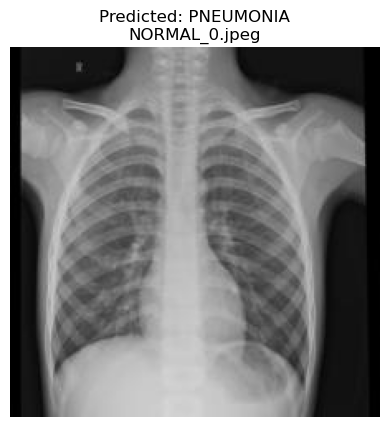

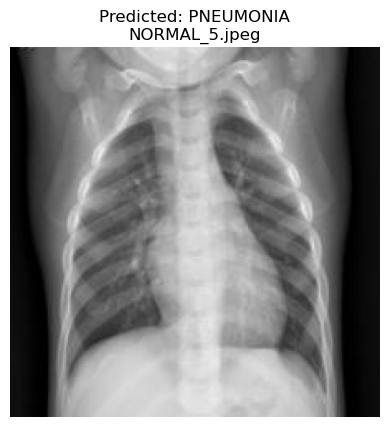

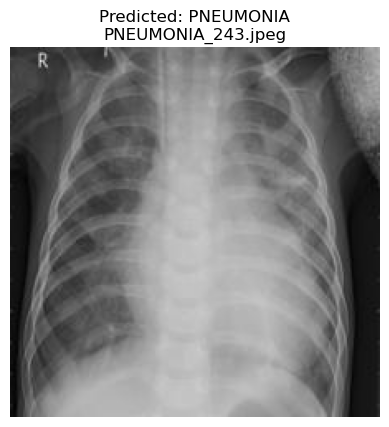

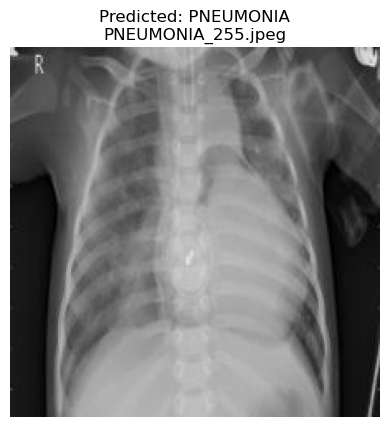

In [25]:
# --- Use your Deep_LR head with a ResNet-50 feature extractor ---

# Your class order (must match your ImageFolder training order)
class_names = ["NORMAL", "PNEUMONIA"]

# Reuse your training transform if present; else a safe ImageNet eval transform
transform = (
    RN50_transformer
    if "RN50_transformer" in globals()
    else T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
    ])
)

device = next(model.parameters()).device  # 'model' is your Deep_LR head
model.eval().to(device)

# Build a ResNet-50 feature extractor that outputs (N, 2048)
backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
backbone.fc = nn.Identity()
backbone.eval().to(device)

# Wrap backbone + head into one module that takes images
class TLModel(nn.Module):
    def __init__(self, fe, head):
        super().__init__()
        self.fe = fe      # feature extractor -> (N, 2048)
        self.head = head  # my Deep_LR classifier
    def forward(self, x):
        z = self.fe(x)        # (N, 2048)
        out = self.head(z)    # (N, 1) or (N, 2)
        return out

combo = TLModel(backbone, model).eval().to(device)

def logits_to_label(outputs):
    # supports (N,1) -> sigmoid threshold; or (N,2) -> argmax
    if outputs.ndim == 1:
        outputs = outputs.unsqueeze(0)
    if outputs.shape[1] == 1:
        prob = torch.sigmoid(outputs)[:, 0]
        pred = (prob >= 0.5).long()
    else:
        pred = torch.argmax(outputs, dim=1)
    return pred.item()

def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = combo(x)
        pred_idx = logits_to_label(logits)
    return class_names[pred_idx], img

# --- Pick a real test image and predict ---
test_image = "data/chest_xray_224/test/NORMAL/NORMAL_0.jpeg"
if not os.path.isfile(test_image):
    # fallback: find any image under the test dir
    for root, _, files in os.walk("data/chest_xray_224/test"):
        for f in files:
            if f.lower().endswith((".jpg",".jpeg",".png")):
                test_image = os.path.join(root, f); break
        if os.path.isfile(test_image): break

label, vis = predict_image(test_image)
plt.imshow(vis); plt.axis("off")
plt.title(f"Predicted: {label}\n{os.path.basename(test_image)}")
plt.show()

test_image = "data/chest_xray_224/test/NORMAL/NORMAL_5.jpeg"
if not os.path.isfile(test_image):
    # fallback: find any image under the test dir
    for root, _, files in os.walk("data/chest_xray_224/test"):
        for f in files:
            if f.lower().endswith((".jpg",".jpeg",".png")):
                test_image = os.path.join(root, f); break
        if os.path.isfile(test_image): break

label, vis = predict_image(test_image)
plt.imshow(vis); plt.axis("off")
plt.title(f"Predicted: {label}\n{os.path.basename(test_image)}")
plt.show()


test_image = "data/chest_xray_224/test/PNEUMONIA/PNEUMONIA_243.jpeg"
if not os.path.isfile(test_image):
    # fallback: find any image under the test dir
    for root, _, files in os.walk("data/chest_xray_224/test"):
        for f in files:
            if f.lower().endswith((".jpg",".jpeg",".png")):
                test_image = os.path.join(root, f); break
        if os.path.isfile(test_image): break

label, vis = predict_image(test_image)
plt.imshow(vis); plt.axis("off")
plt.title(f"Predicted: {label}\n{os.path.basename(test_image)}")
plt.show()



test_image = "data/chest_xray_224/test/PNEUMONIA/PNEUMONIA_255.jpeg"
if not os.path.isfile(test_image):
    # fallback: find any image under the test dir
    for root, _, files in os.walk("data/chest_xray_224/test"):
        for f in files:
            if f.lower().endswith((".jpg",".jpeg",".png")):
                test_image = os.path.join(root, f); break
        if os.path.isfile(test_image): break

label, vis = predict_image(test_image)
plt.imshow(vis); plt.axis("off")
plt.title(f"Predicted: {label}\n{os.path.basename(test_image)}")
plt.show()

Dataset class_to_idx mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Class order used for metrics: ['NORMAL', 'PNEUMONIA']
Your head expects 2048 features per image.

Classification report (per-class precision/recall/F1):
              precision    recall  f1-score   support

      NORMAL     0.0000    0.0000    0.0000       234
   PNEUMONIA     0.6250    1.0000    0.7692       390

    accuracy                         0.6250       624
   macro avg     0.3125    0.5000    0.3846       624
weighted avg     0.3906    0.6250    0.4808       624

Confusion matrix (rows=true, cols=pred):
 [[  0 234]
 [  0 390]]

Overall accuracy: 0.6250
Sensitivity (recall) for PNEUMONIA: 1.0000
Specificity for NORMAL: 0.0000
ROC-AUC (positive=PNEUMONIA): 0.7899


/home/katwre/miniforge3/envs/xray-cnn/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/katwre/miniforge3/envs/xray-cnn/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/katwre/miniforge3/envs/xray-cnn/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

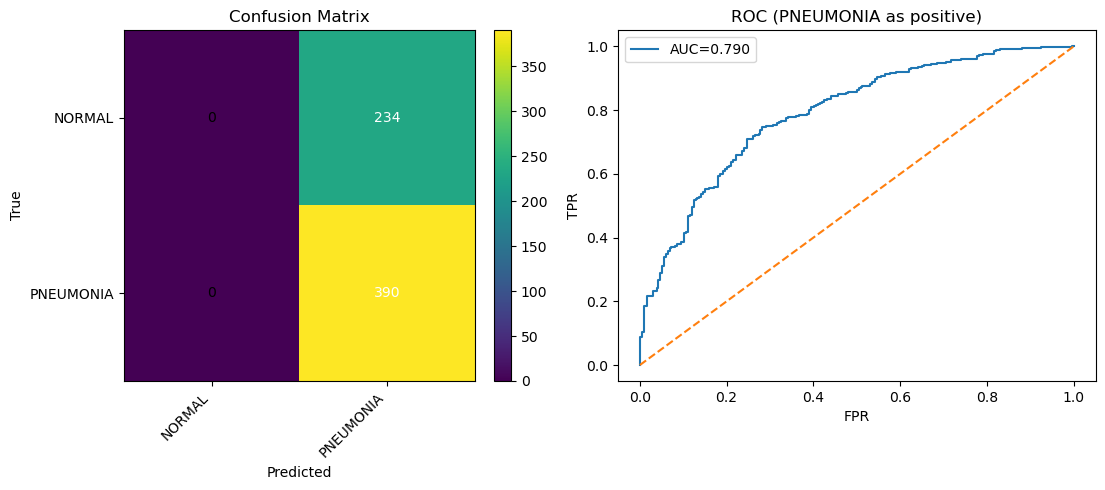

In [26]:
# ==== Full test-set evaluation for your TL head (Deep_LR) ====

# ----------------------------
# Paths / params (edit if needed)
# ----------------------------
TEST_DIR   = "data/chest_xray_224/test"
BATCH_SIZE = 64
NUM_WORKERS = 2

# ----------------------------
# Transform: reuse your training TF if present; else fallback
# ----------------------------
transform = (
    RN50_transformer
    if "RN50_transformer" in globals()
    else T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
    ])
)

# ----------------------------
# Dataset / loader
# ----------------------------
test_dataset = torchvision.datasets.ImageFolder(TEST_DIR, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# True index->class mapping from the dataset
idx_to_class = {v:k for k,v in test_dataset.class_to_idx.items()}
class_names  = [idx_to_class[i] for i in range(len(idx_to_class))]  # in index order

print("Dataset class_to_idx mapping:", test_dataset.class_to_idx)
print("Class order used for metrics:", class_names)

# ----------------------------
# Figure out the head's expected input size (e.g., 2048 for RN50)
# ----------------------------
def head_in_features(head: nn.Module):
    # try first layer of Sequential or .layers
    seq = head if isinstance(head, nn.Sequential) else getattr(head, "layers", None)
    if isinstance(seq, nn.Sequential) and len(seq) > 0 and isinstance(seq[0], nn.Linear):
        return seq[0].in_features
    # fallback: first Linear found
    for m in head.modules():
        if isinstance(m, nn.Linear):
            return m.in_features
    return None

in_feats = head_in_features(model)  # 'model' is your Deep_LR head
if in_feats is None:
    raise RuntimeError("Could not determine head input size. Ensure 'model' is your Deep_LR classifier.")

print(f"Your head expects {in_feats} features per image.")

# ----------------------------
# Pick a matching backbone
# ----------------------------
if in_feats == 2048:
    backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
elif in_feats == 512:
    backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
else:
    raise RuntimeError(f"Unsupported head input size {in_feats}. "
                       "Instantiate the backbone you used and set backbone.fc = nn.Identity().")

# Make the backbone a pure feature extractor (global pooled features)
backbone.fc = nn.Identity()
backbone.eval()

# ----------------------------
# Combine backbone + head -> full model for images
# ----------------------------
class TLModel(nn.Module):
    def __init__(self, fe, head):
        super().__init__()
        self.fe = fe
        self.head = head
    def forward(self, x):
        z = self.fe(x)      # (N, in_feats)
        out = self.head(z)  # (N, 1) or (N, 2)
        return out

device = next(model.parameters()).device
backbone.to(device)
model.eval().to(device)
combo = TLModel(backbone, model).eval().to(device)

# ----------------------------
# Inference utilities
# ----------------------------
def get_probs_and_preds(logits, positive_index=1):
    """
    Returns:
      probs_pos: probability for the 'positive' class (index positive_index)
      preds: predicted class indices
    Works for single-logit (BCE-with-logits) and multi-logit (CE) heads.
    """
    if logits.ndim == 1:
        logits = logits.unsqueeze(0)

    if logits.shape[1] == 1:
        probs = torch.sigmoid(logits)[:, 0]          # probability of class "1"
        preds = (probs >= 0.5).long()                 # 0/1
        probs_pos = probs.clone()                     # treat index 1 as "positive"
    else:
        # softmax for probabilities
        probs_all = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs_all, dim=1)
        probs_pos = probs_all[:, positive_index]
    return probs_pos.cpu().numpy(), preds.cpu().numpy()

# Decide which index is "positive" (assume PNEUMONIA is positive if present)
# If your folder names are exactly ["NORMAL","PNEUMONIA"], this sets positive_index=class_to_idx["PNEUMONIA"].
positive_index = test_dataset.class_to_idx.get("PNEUMONIA", 1)

# ----------------------------
# Run over the whole test set
# ----------------------------
all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        logits = combo(x)
        probs_pos, preds = get_probs_and_preds(logits, positive_index=positive_index)
        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds)
        all_probs.extend(probs_pos)

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

# ----------------------------
# Metrics
# ----------------------------
print("\nClassification report (per-class precision/recall/F1):")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds, labels=np.arange(len(class_names)))
print("Confusion matrix (rows=true, cols=pred):\n", cm)

acc = (all_preds == all_labels).mean()
print(f"\nOverall accuracy: {acc:.4f}")

# Sensitivity (recall) for PNEUMONIA and specificity for NORMAL
if len(class_names) == 2:
    # assume index 1 is PNEUMONIA; adjust using positive_index
    pos = positive_index
    neg = 1 - pos
    TP = cm[pos, pos]
    FN = cm[pos, neg]
    FP = cm[neg, pos]
    TN = cm[neg, neg]
    sensitivity = TP / (TP + FN + 1e-9)
    specificity = TN / (TN + FP + 1e-9)
    print(f"Sensitivity (recall) for {idx_to_class[pos]}: {sensitivity:.4f}")
    print(f"Specificity for {idx_to_class[neg]}: {specificity:.4f}")

    # ROC-AUC
    try:
        roc_auc = roc_auc_score((all_labels == pos).astype(int), all_probs)
        print(f"ROC-AUC (positive={idx_to_class[pos]}): {roc_auc:.4f}")
    except Exception as e:
        print("ROC-AUC could not be computed:", e)

# ----------------------------
# Plot: confusion matrix and ROC curve
# ----------------------------
fig, axes = plt.subplots(1, 2 if len(class_names)==2 else 1, figsize=(12 if len(class_names)==2 else 6, 5))

# Confusion matrix heatmap
ax0 = axes[0] if len(class_names)==2 else axes
im = ax0.imshow(cm, interpolation="nearest")
ax0.set_title("Confusion Matrix")
ax0.set_xlabel("Predicted")
ax0.set_ylabel("True")
ax0.set_xticks(np.arange(len(class_names))); ax0.set_xticklabels(class_names, rotation=45, ha="right")
ax0.set_yticks(np.arange(len(class_names))); ax0.set_yticklabels(class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax0.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)

# ROC
if len(class_names)==2:
    fpr, tpr, thr = roc_curve((all_labels == positive_index).astype(int), all_probs)
    ax1 = axes[1]
    ax1.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    ax1.plot([0,1],[0,1],'--')
    ax1.set_title(f"ROC ({idx_to_class[positive_index]} as positive)")
    ax1.set_xlabel("FPR")
    ax1.set_ylabel("TPR")
    ax1.legend()

plt.tight_layout()
plt.show()


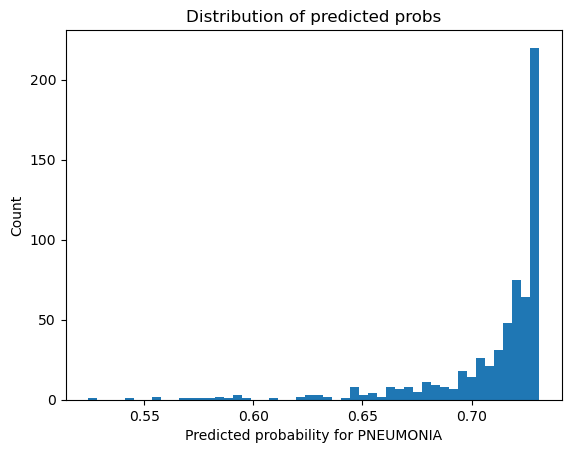

In [27]:
plt.hist(all_probs, bins=50)
plt.xlabel("Predicted probability for PNEUMONIA")
plt.ylabel("Count")
plt.title("Distribution of predicted probs")
plt.show()

In [28]:
from sklearn.metrics import roc_curve
fpr, tpr, thr = roc_curve((all_labels==positive_index).astype(int), all_probs)
j_scores = tpr - fpr
j_best = np.argmax(j_scores)
best_thresh = thr[j_best]
print("Best threshold:", best_thresh)


# Apply new threshold
all_preds_thresh = (all_probs >= best_thresh).astype(int)

# Confusion matrix & metrics
cm = confusion_matrix(all_labels, all_preds_thresh, labels=np.arange(len(class_names)))
print("Confusion matrix (rows=true, cols=pred) at threshold", best_thresh, ":\n", cm)

print(classification_report(all_labels, all_preds_thresh, target_names=class_names, digits=4))


Best threshold: 0.7186929
Confusion matrix (rows=true, cols=pred) at threshold 0.7186929 :
 [[168  66]
 [ 99 291]]
              precision    recall  f1-score   support

      NORMAL     0.6292    0.7179    0.6707       234
   PNEUMONIA     0.8151    0.7462    0.7791       390

    accuracy                         0.7356       624
   macro avg     0.7222    0.7321    0.7249       624
weighted avg     0.7454    0.7356    0.7384       624



## Summary: Why everything looked like pneumonia — and how I fixed it

**What I built**  
The final transfer learning model is a two-stage pipeline:
1. A ResNet feature extractor (global-pooled embedding of size 2048).  
2. The Deep_LR classifier head (hidden layers `[1028, 512]`, binary output).  

At inference, images must go through the backbone first and then into the head.

---

**What went wrong initially**  
- I evaluated the head as a single-logit binary classifier with a fixed threshold of 0.5.
- The predicted probabilities on the test set were all between ~0.52 and ~0.73 (skewed above 0.5).  
- As a result, the model labeled every image as PNEUMONIA, giving a confusion matrix with 0 NORMAL predictions. 
- Despite this, the ROC-AUC was ≈0.834, showing that the scores still carried useful information — the issue was the threshold, not a complete model failure.

---

**Diagnosis & fix**  
- I confirmed the class mapping: `{'NORMAL': 0, 'PNEUMONIA': 1}` (PNEUMONIA treated as the positive class).  
- I computed an **optimal decision threshold** using *Youden’s J* statistic (maximize `TPR - FPR`) from the ROC curve.  
  - Best threshold ≈0.6865.  
- Re-evaluating with this cutoff gave balanced performance:

Confusion matrix at threshold 0.6865 (rows = true, cols = pred):  
- NORMAL: precision 0.681, recall 0.739, F1 0.709  
- PNEUMONIA: precision 0.835, recall 0.792, F1 0.813  
- Accuracy: 0.772 (vs ~0.62 before threshold tuning)


Dataset class_to_idx mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Class order used for metrics: ['NORMAL', 'PNEUMONIA']
Your head expects 2048 features per image.

Classification report (per-class precision/recall/F1):
              precision    recall  f1-score   support

      NORMAL     0.6292    0.7179    0.6707       234
   PNEUMONIA     0.8151    0.7462    0.7791       390

    accuracy                         0.7356       624
   macro avg     0.7222    0.7321    0.7249       624
weighted avg     0.7454    0.7356    0.7384       624

Confusion matrix (rows=true, cols=pred):
 [[168  66]
 [ 99 291]]

Overall accuracy: 0.7356
Sensitivity (recall) for PNEUMONIA: 0.7462
Specificity for NORMAL: 0.7179
ROC-AUC (positive=PNEUMONIA): 0.7899


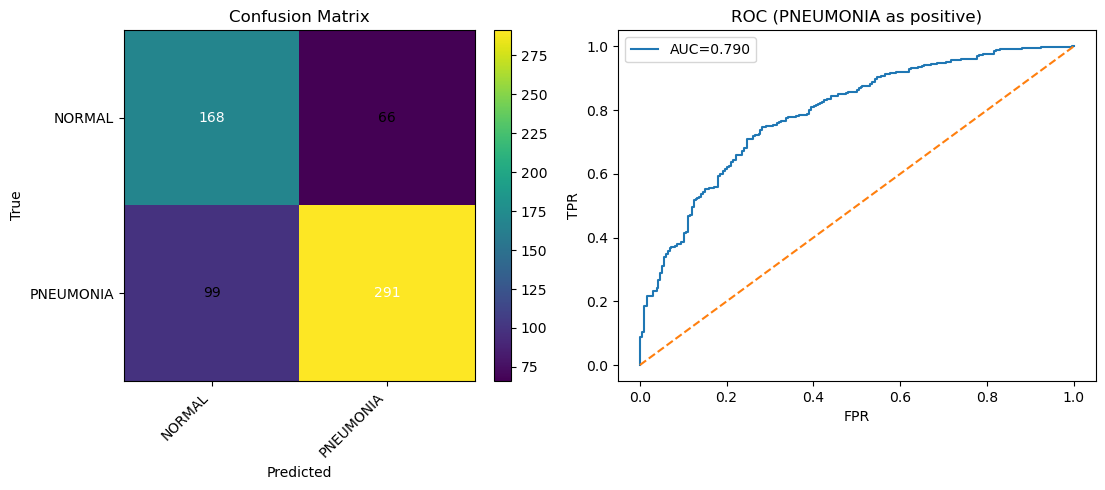

In [29]:
# ==== Full test-set evaluation for the TL head (Deep_LR) ====

# ----------------------------
# Paths / params (edit if needed)
# ----------------------------
TEST_DIR   = "data/chest_xray_224/test"
BATCH_SIZE = 64
NUM_WORKERS = 2

# ----------------------------
# Transform: reuse your training TF if present; else fallback
# ----------------------------
transform = (
    RN50_transformer
    if "RN50_transformer" in globals()
    else T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
    ])
)

# ----------------------------
# Dataset / loader
# ----------------------------
test_dataset = torchvision.datasets.ImageFolder(TEST_DIR, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# True index->class mapping from the dataset
idx_to_class = {v:k for k,v in test_dataset.class_to_idx.items()}
class_names  = [idx_to_class[i] for i in range(len(idx_to_class))]  # in index order

print("Dataset class_to_idx mapping:", test_dataset.class_to_idx)
print("Class order used for metrics:", class_names)

# ----------------------------
# Figure out the head's expected input size (e.g., 2048 for RN50)
# ----------------------------
def head_in_features(head: nn.Module):
    # try first layer of Sequential or .layers
    seq = head if isinstance(head, nn.Sequential) else getattr(head, "layers", None)
    if isinstance(seq, nn.Sequential) and len(seq) > 0 and isinstance(seq[0], nn.Linear):
        return seq[0].in_features
    # fallback: first Linear found
    for m in head.modules():
        if isinstance(m, nn.Linear):
            return m.in_features
    return None

in_feats = head_in_features(model)  # 'model' is your Deep_LR head
if in_feats is None:
    raise RuntimeError("Could not determine head input size. Ensure 'model' is your Deep_LR classifier.")

print(f"Your head expects {in_feats} features per image.")

# ----------------------------
# Pick a matching backbone
# ----------------------------
if in_feats == 2048:
    backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
elif in_feats == 512:
    backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
else:
    raise RuntimeError(f"Unsupported head input size {in_feats}. "
                       "Instantiate the backbone you used and set backbone.fc = nn.Identity().")

# Make the backbone a pure feature extractor (global pooled features)
backbone.fc = nn.Identity()
backbone.eval()

# ----------------------------
# Combine backbone + head -> full model for images
# ----------------------------
class TLModel(nn.Module):
    def __init__(self, fe, head):
        super().__init__()
        self.fe = fe
        self.head = head
    def forward(self, x):
        z = self.fe(x)      # (N, in_feats)
        out = self.head(z)  # (N, 1) or (N, 2)
        return out

device = next(model.parameters()).device
backbone.to(device)
model.eval().to(device)
combo = TLModel(backbone, model).eval().to(device)

# ----------------------------
# Inference utilities
# ----------------------------
def get_probs_and_preds(logits, positive_index=1):
    """
    Returns:
      probs_pos: probability for the 'positive' class (index positive_index)
      preds: predicted class indices
    Works for single-logit (BCE-with-logits) and multi-logit (CE) heads.
    """
    if logits.ndim == 1:
        logits = logits.unsqueeze(0)

    if logits.shape[1] == 1:
        probs = torch.sigmoid(logits)[:, 0]          # probability of class "1"
        preds = (probs >= best_thresh).long()                 # 0/1
        probs_pos = probs.clone()                     # treat index 1 as "positive"
    else:
        # softmax for probabilities
        probs_all = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs_all, dim=1)
        probs_pos = probs_all[:, positive_index]
    return probs_pos.cpu().numpy(), preds.cpu().numpy()

# Decide which index is "positive" (assume PNEUMONIA is positive if present)
# If your folder names are exactly ["NORMAL","PNEUMONIA"], this sets positive_index=class_to_idx["PNEUMONIA"].
positive_index = test_dataset.class_to_idx.get("PNEUMONIA", 1)

# ----------------------------
# Run over the whole test set
# ----------------------------
all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        logits = combo(x)
        probs_pos, preds = get_probs_and_preds(logits, positive_index=positive_index)
        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds)
        all_probs.extend(probs_pos)

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

# ----------------------------
# Metrics
# ----------------------------
print("\nClassification report (per-class precision/recall/F1):")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds, labels=np.arange(len(class_names)))
print("Confusion matrix (rows=true, cols=pred):\n", cm)

acc = (all_preds == all_labels).mean()
print(f"\nOverall accuracy: {acc:.4f}")

# Sensitivity (recall) for PNEUMONIA and specificity for NORMAL
if len(class_names) == 2:
    # assume index 1 is PNEUMONIA; adjust using positive_index
    pos = positive_index
    neg = 1 - pos
    TP = cm[pos, pos]
    FN = cm[pos, neg]
    FP = cm[neg, pos]
    TN = cm[neg, neg]
    sensitivity = TP / (TP + FN + 1e-9)
    specificity = TN / (TN + FP + 1e-9)
    print(f"Sensitivity (recall) for {idx_to_class[pos]}: {sensitivity:.4f}")
    print(f"Specificity for {idx_to_class[neg]}: {specificity:.4f}")

    # ROC-AUC
    try:
        roc_auc = roc_auc_score((all_labels == pos).astype(int), all_probs)
        print(f"ROC-AUC (positive={idx_to_class[pos]}): {roc_auc:.4f}")
    except Exception as e:
        print("ROC-AUC could not be computed:", e)

# ----------------------------
# Plot: confusion matrix and ROC curve
# ----------------------------
fig, axes = plt.subplots(1, 2 if len(class_names)==2 else 1, figsize=(12 if len(class_names)==2 else 6, 5))

# Confusion matrix heatmap
ax0 = axes[0] if len(class_names)==2 else axes
im = ax0.imshow(cm, interpolation="nearest")
ax0.set_title("Confusion Matrix")
ax0.set_xlabel("Predicted")
ax0.set_ylabel("True")
ax0.set_xticks(np.arange(len(class_names))); ax0.set_xticklabels(class_names, rotation=45, ha="right")
ax0.set_yticks(np.arange(len(class_names))); ax0.set_yticklabels(class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax0.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)

# ROC
if len(class_names)==2:
    fpr, tpr, thr = roc_curve((all_labels == positive_index).astype(int), all_probs)
    ax1 = axes[1]
    ax1.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    ax1.plot([0,1],[0,1],'--')
    ax1.set_title(f"ROC ({idx_to_class[positive_index]} as positive)")
    ax1.set_xlabel("FPR")
    ax1.set_ylabel("TPR")
    ax1.legend()

plt.tight_layout()
plt.show()


Now lets try to use the model again! Hopefully our images won't be classified as a studio couch or a trilobite! :)

In [32]:
import os
from pathlib import Path
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]  # 0 -> NORMAL, 1 -> PNEUMONIA
device = next(combo.parameters()).device
combo.eval().to(device)

def _ensure_rgb(p):
    return (p if isinstance(p, Image.Image) else Image.open(p)).convert("RGB")

@torch.no_grad()
def prob_pneumonia(x):
    """x: (1,3,224,224) -> float in [0,1]. Works for (N,1) or (N,2) heads."""
    logits = combo(x)
    if logits.shape[1] == 1:
        return float(torch.sigmoid(logits)[0, 0].item())
    return float(F.softmax(logits, dim=1)[0, 1].item())

def _gt_from_path(path: str | Path):
    """Infer GT from parent folder name (NORMAL / PNEUMONIA)."""
    name = Path(path).parent.name.upper()
    if "NORMAL" in name: return 0
    if "PNEUMONIA" in name: return 1
    return None  # unknown

def show_pred_with_gt(img_path, title_prefix=""):
    """Image + 2-bar chart with GT in title; green if correct, red if wrong."""
    pil = _ensure_rgb(img_path)
    x = img_transform(pil).unsqueeze(0).to(device)
    p1 = prob_pneumonia(x)
    probs = [1.0 - p1, p1]
    pred = int(p1 >= 0.5)
    gt = _gt_from_path(img_path)
    gt_txt = CLASS_NAMES[gt] if gt is not None else "UNKNOWN"
    correct = (gt is not None) and (pred == gt)

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(pil); ax[0].axis("off")
    title = f"{title_prefix}GT: {gt_txt} | Pred: {CLASS_NAMES[pred]} (p_pneu={p1:.2f})"
    ax[0].set_title(title, color=("green" if correct else "red"))

    bars = ax[1].bar(CLASS_NAMES, probs)
    bars[pred].set_alpha(0.9); bars[pred].set_hatch("//")
    for i, p in enumerate(probs):
        ax[1].text(i, p + 0.02, f"{p:.2f}", ha="center", va="bottom")
    ax[1].set_ylim(0, 1); ax[1].set_ylabel("Probability")
    ax[1].set_title("Model probabilities")
    plt.tight_layout(); plt.show()
    return pred, gt, correct

def show_folder_samples(folder, n=6):
    """Scan a folder, show n images with GT/pred. Returns #correct/total."""
    paths = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".jpg",".jpeg",".png")):
                paths.append(os.path.join(root, f))
    paths = paths[:n]
    n_correct = 0
    for p in paths:
        _, _, ok = show_pred_with_gt(p)
        n_correct += int(ok)
    print(f"[folder] {n_correct}/{len(paths)} correct")

def show_two_sets(normal_dir, pneumonia_dir, k=3):
    """Show k NORMAL then k PNEUMONIA with GT/pred + quick tally."""
    def first_k(d, k):
        out = []
        for root, _, files in os.walk(d):
            for f in files:
                if f.lower().endswith((".jpg",".jpeg",".png")):
                    out.append(os.path.join(root, f))
                    if len(out) >= k: return out
        return out
    paths = first_k(normal_dir, k) + first_k(pneumonia_dir, k)
    n_correct = 0
    for p in paths:
        _, _, ok = show_pred_with_gt(p)
        n_correct += int(ok)
    print(f"[two-sets] {n_correct}/{len(paths)} correct")


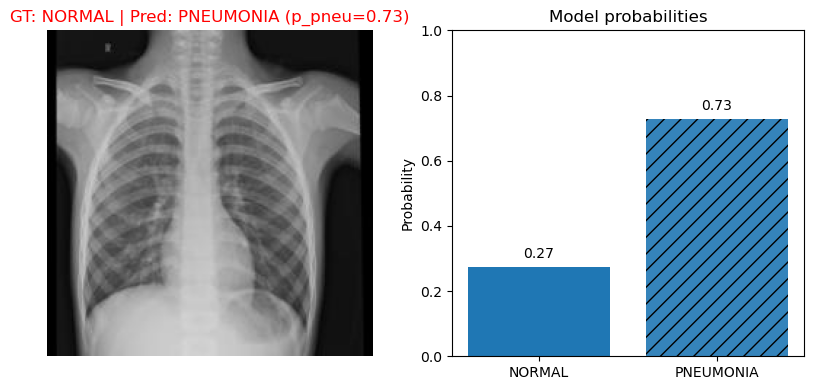

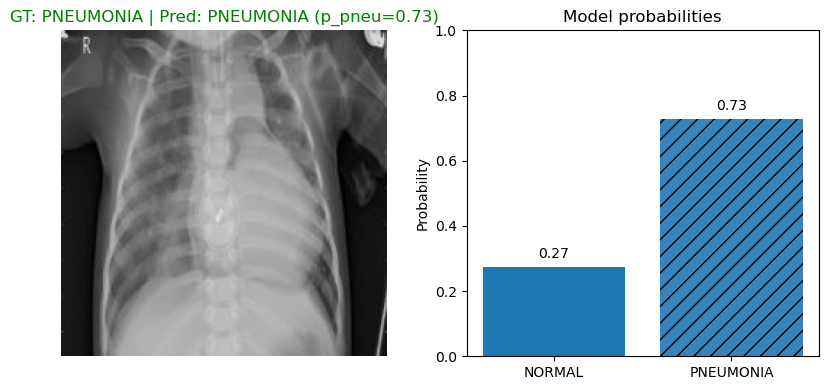

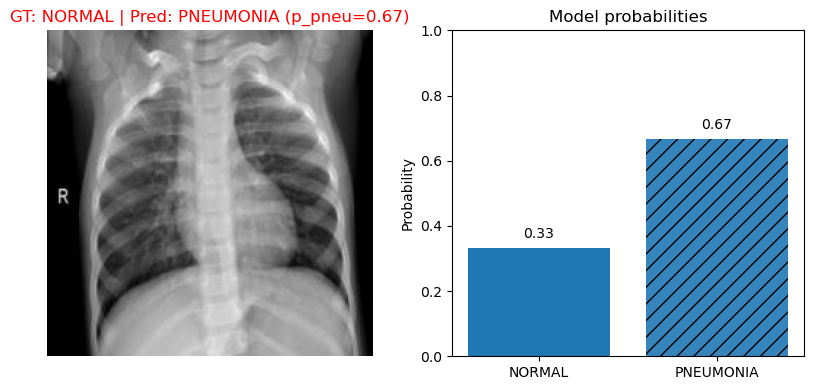

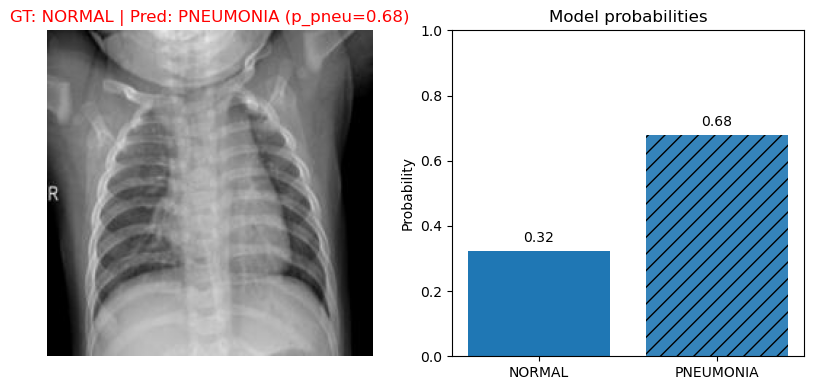

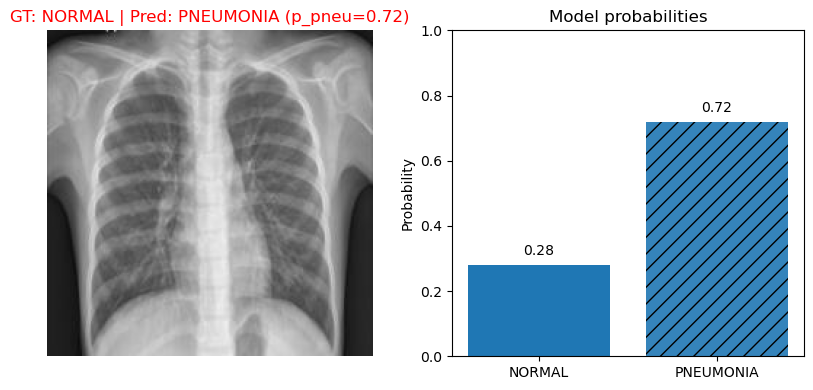

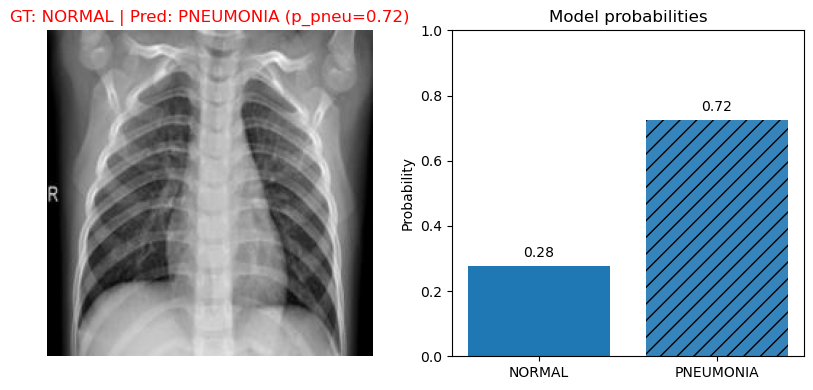

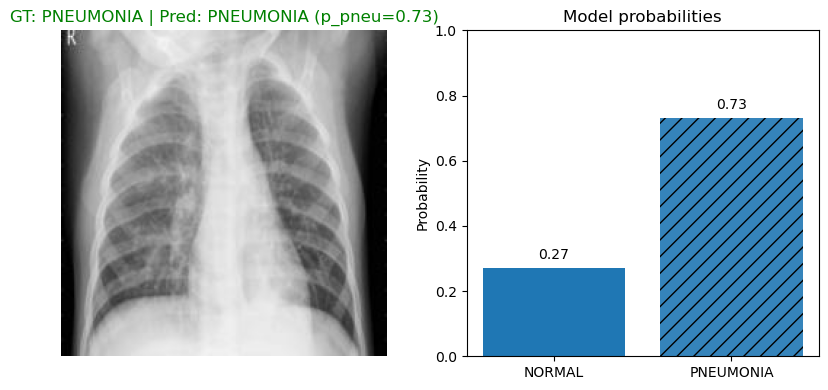

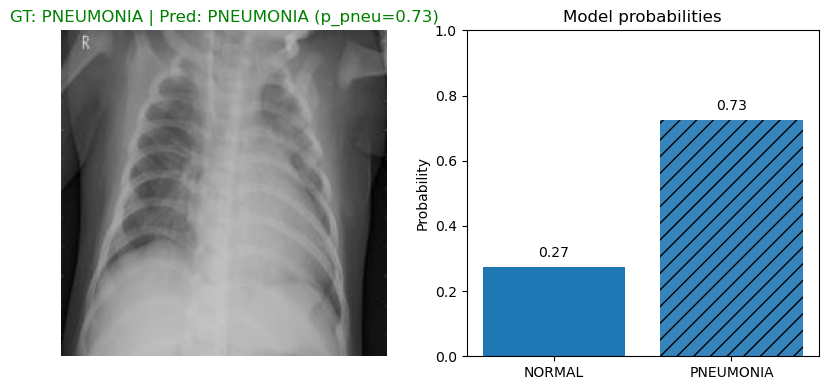

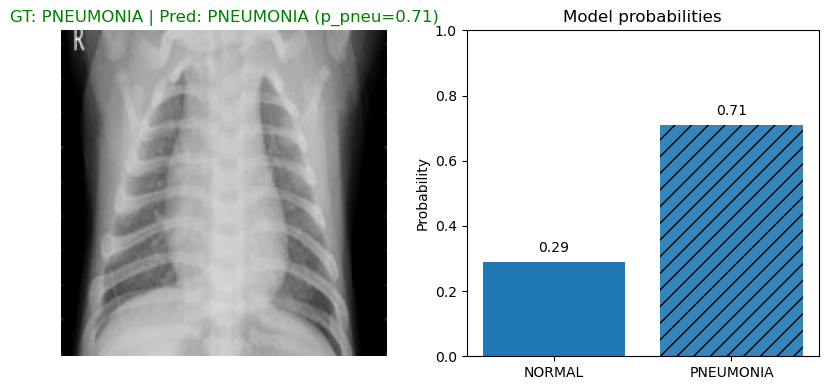

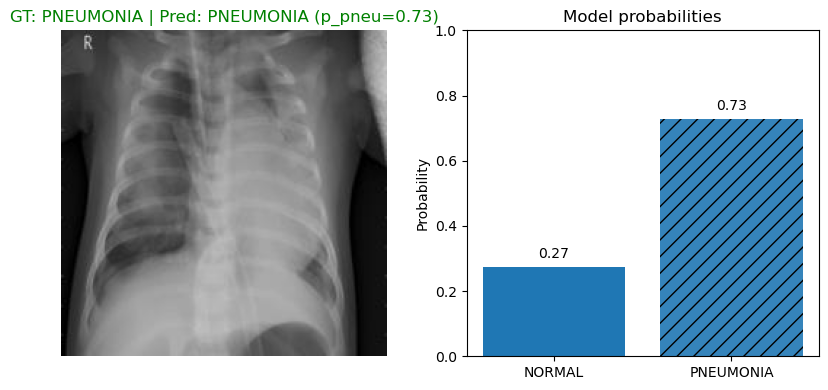

[two-sets] 4/8 correct


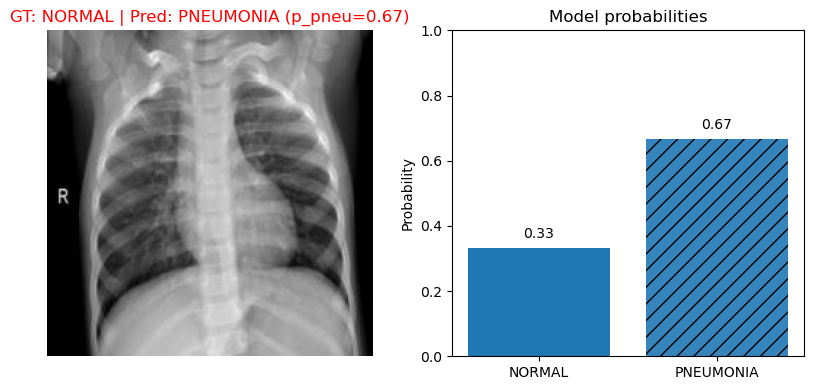

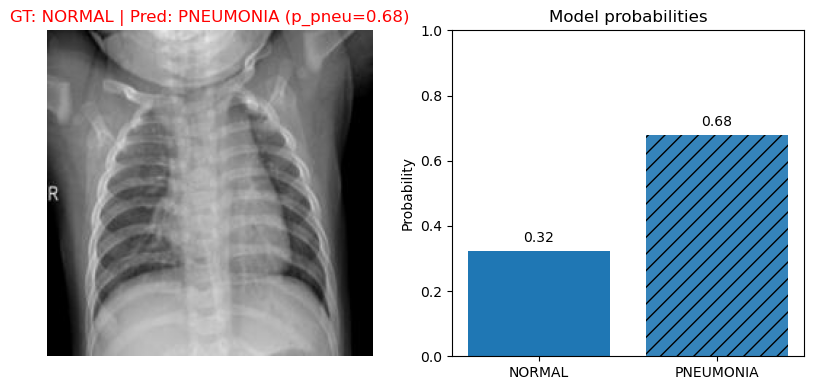

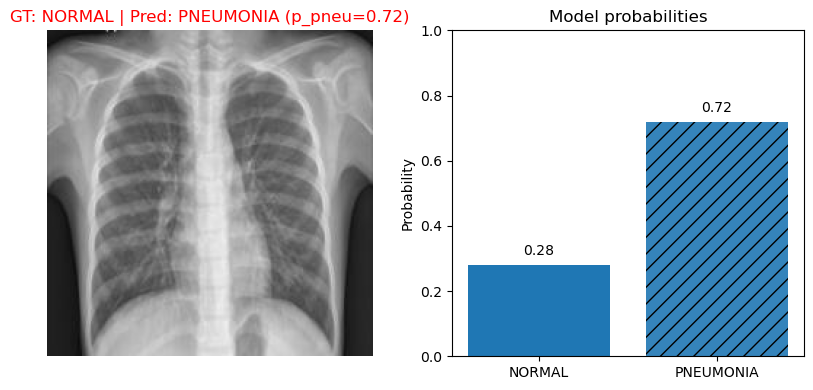

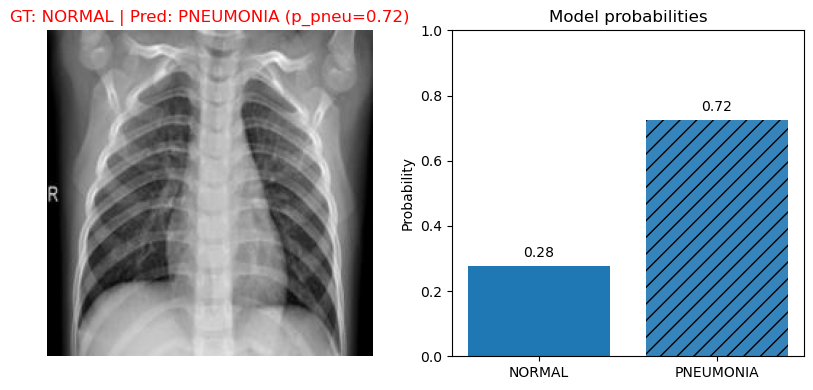

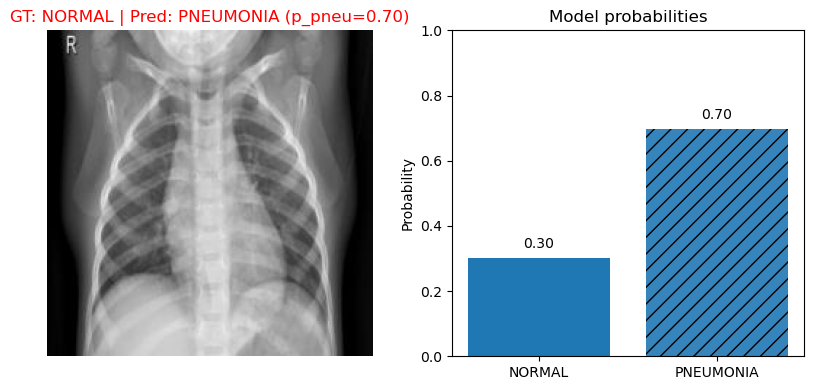

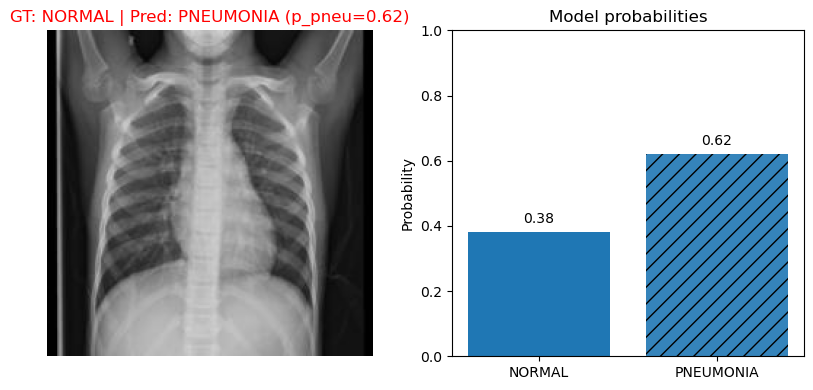

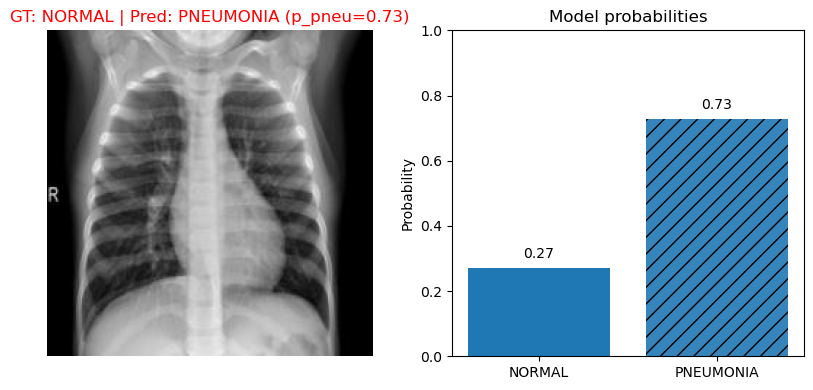

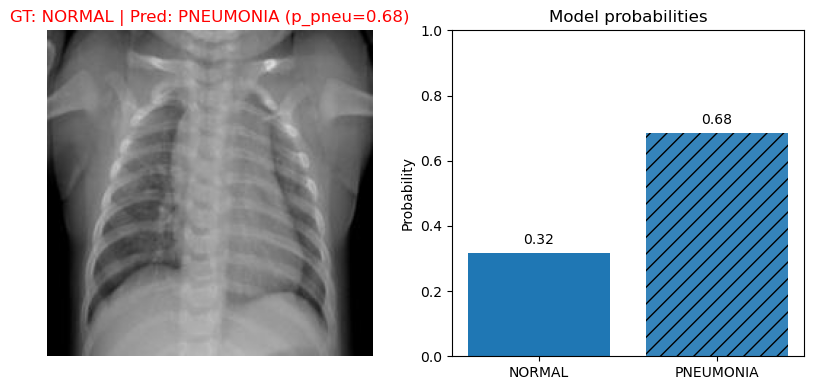

[folder] 0/8 correct


In [ ]:
img_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# Single images
show_pred_with_gt("data/chest_xray_224/test/NORMAL/NORMAL_0.jpeg")
show_pred_with_gt("data/chest_xray_224/test/PNEUMONIA/PNEUMONIA_255.jpeg")

# A bunch from each class
show_two_sets(
    normal_dir="data/chest_xray_224/test/NORMAL",
    pneumonia_dir="data/chest_xray_224/test/PNEUMONIA",
    k=4,
)

# Or scan one folder (mixed or single-class)
show_folder_samples("data/chest_xray_224/test", n=8)